In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

In [10]:
# Read expression matrix and samples
expr = pd.read_csv('data/expression_matrix.csv', index_col='gene_id')
metadata = pd.read_csv('data/sample_metadata.csv', index_col='sample_id')

# Align samples
samples = expr.columns.intersection(metadata.index)
expr = expr[samples]
metadata = metadata.loc[samples]

tumor_samples  = metadata[metadata['condition'] == 'tumor'].index
normal_samples = metadata[metadata['condition'] == 'normal'].index

# Per-gene statistics
mean_tumor  = expr[tumor_samples].mean(axis=1)
mean_normal = expr[normal_samples].mean(axis=1)
log2fc      = mean_tumor - mean_normal   # log2 fold-change (already in log2 space)

# Per-gene p-value (Welch t-test, one per gene)
pvalues = expr.apply(
    lambda row: stats.ttest_ind(
        row[tumor_samples], row[normal_samples], equal_var=False
    ).pvalue,
    axis=1
)
neg_log10_p = -np.log10(pvalues.clip(lower=1e-300))

print(f"Genes: {expr.shape[0]}  |  Tumor samples: {len(tumor_samples)}  |  Normal samples: {len(normal_samples)}")

Genes: 200  |  Tumor samples: 40  |  Normal samples: 20


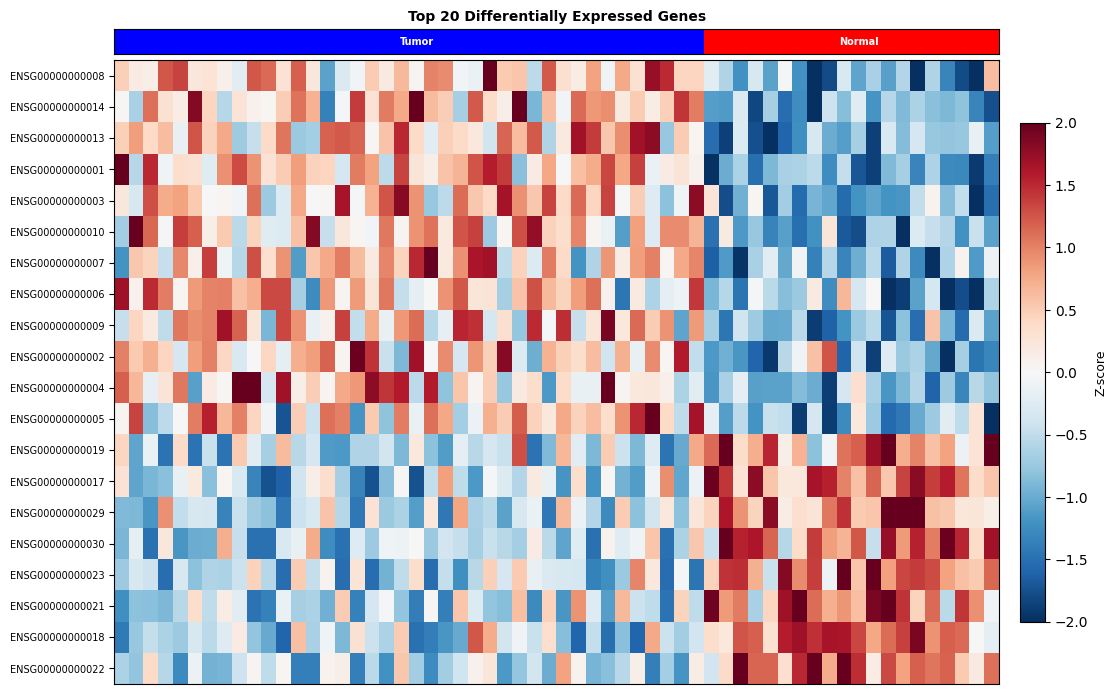

In [11]:
def expressionHeatmap(ax, expr, metadata):
    """T1.2 — Draws a heatmap of the top 20 most differentially expressed genes.
    Samples ordered: tumour (by cancer type) then normal.
    Genes ordered by log2FC (most overexpressed at top).
    Z-score normalised per gene, diverging colourmap (RdBu_r).
    """

    top20 = log2fc.abs().sort_values(ascending=False).head(20).index
    top20 = log2fc[top20].sort_values(ascending=False).index

    tumor_data  = metadata[metadata['condition'] == 'tumor'].sort_values('cancer_type')
    normal_data = metadata[metadata['condition'] == 'normal'].sort_values('cancer_type')

    expr_top = pd.concat([expr[tumor_data.index], expr[normal_data.index]], axis=1).loc[top20]

    # Z-score normalized per gene
    z_scores = expr_top.subtract(expr_top.mean(axis=1), axis=0).divide(expr_top.std(axis=1), axis=0)

    # Heatmap with diverging colormap
    im = ax.imshow(z_scores.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)

    ax.set_yticks(range(20))
    ax.set_yticklabels(top20, fontsize=7)
    ax.set_xticks([])
    ax.set_title('Top 20 Differentially Expressed Genes', fontsize=10, fontweight='bold')

    cbar = ax.get_figure().colorbar(im, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label('Z-score', fontsize=9)

    # Annotation above heatmap for tumor and normal samples
    n_t, n_n = len(tumor_data), len(normal_data)
    ax2 = ax.inset_axes([0, 1.01, 1, 0.04])
    ax2.imshow([[0]*n_t + [1]*n_n], aspect='auto', cmap='bwr', vmin=0, vmax=1)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.text(n_t/2,        0, 'Tumor', ha='center', va='center', fontsize=7, fontweight='bold', color='white')
    ax2.text(n_t + n_n/2,  0, 'Normal', ha='center', va='center', fontsize=7, fontweight='bold', color='white')

# Test
fig, ax = plt.subplots(figsize=(12, 7))
expressionHeatmap(ax, expr, metadata)
plt.tight_layout()
plt.savefig('expression_heatmap.png', dpi=150)
plt.show()

##### T3 - Maps #####

In [12]:
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import Point

occurrences = pd.read_csv('data/species_occurrences.csv').dropna(subset=['decimalLatitude','decimalLongitude'])
world       = gpd.read_file('data/countries.geojson')  # ISO3166-1-Alpha-3 column

species_list = sorted(occurrences['species'].unique())
print(f"{len(occurrences)} occurrence records | {len(species_list)} species")
print(occurrences.head())

575 occurrence records | 5 species
        species  decimalLatitude  decimalLongitude  year country  \
0  Panthera leo           2.7396           36.9499  1999     KEN   
1  Panthera leo          -4.0582           41.7806  2017     KEN   
2  Panthera leo           2.8606           34.1530  2016     KEN   
3  Panthera leo           4.2676           38.7948  1999     KEN   
4  Panthera leo          -0.5659           35.0451  1984     KEN   

        basisOfRecord  
0  PRESERVED_SPECIMEN  
1  PRESERVED_SPECIMEN  
2   HUMAN_OBSERVATION  
3  PRESERVED_SPECIMEN  
4   HUMAN_OBSERVATION  


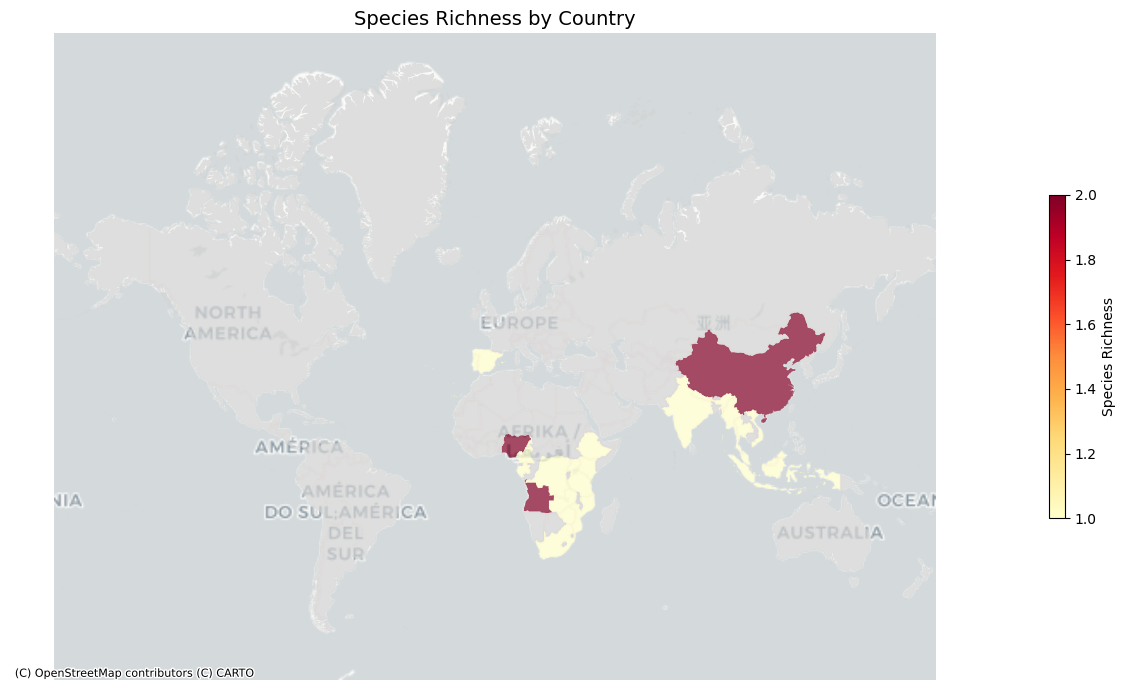

In [13]:
import contextily as ctx

def drawSpeciesRichness(ax, occurrences, world):
    """T3.1 — Draws a world choropleth map of species richness (n distinct species)
    per country. Countries with no data in light grey.
    Colour bar, title, basemap via contextily.
    """

    # Count distinct species per country
    richness = occurrences.groupby('country')['species'].nunique().reset_index()
    richness.columns = ['country', 'richness']

    # Merge with world GeoDataFrame
    world_richness = world.merge(richness, left_on='ISO3166-1-Alpha-3', right_on='country', how='left')

    # Reproject to Web Mercator for contextily compatibility
    world_richness = world_richness[world_richness['ISO3166-1-Alpha-3'] != 'ATA'].to_crs(epsg=3857)

    # Plot
    world_richness.plot(
        column='richness', 
        ax=ax, 
        cmap='YlOrRd',
        legend=True,
        alpha=0.7, 
        legend_kwds={'label': 'Species Richness', 'orientation': 'vertical', 'shrink': 0.5},
        missing_kwds={'color': 'lightgrey', 'label': 'No data'}
    )
    
    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    ax.set_title('Species Richness by Country', fontsize=14)
    ax.set_axis_off()

# Test
fig, ax = plt.subplots(figsize=(14, 7))
drawSpeciesRichness(ax, occurrences, world)
plt.tight_layout()
plt.savefig('species_richness.png', dpi=150)
plt.show()


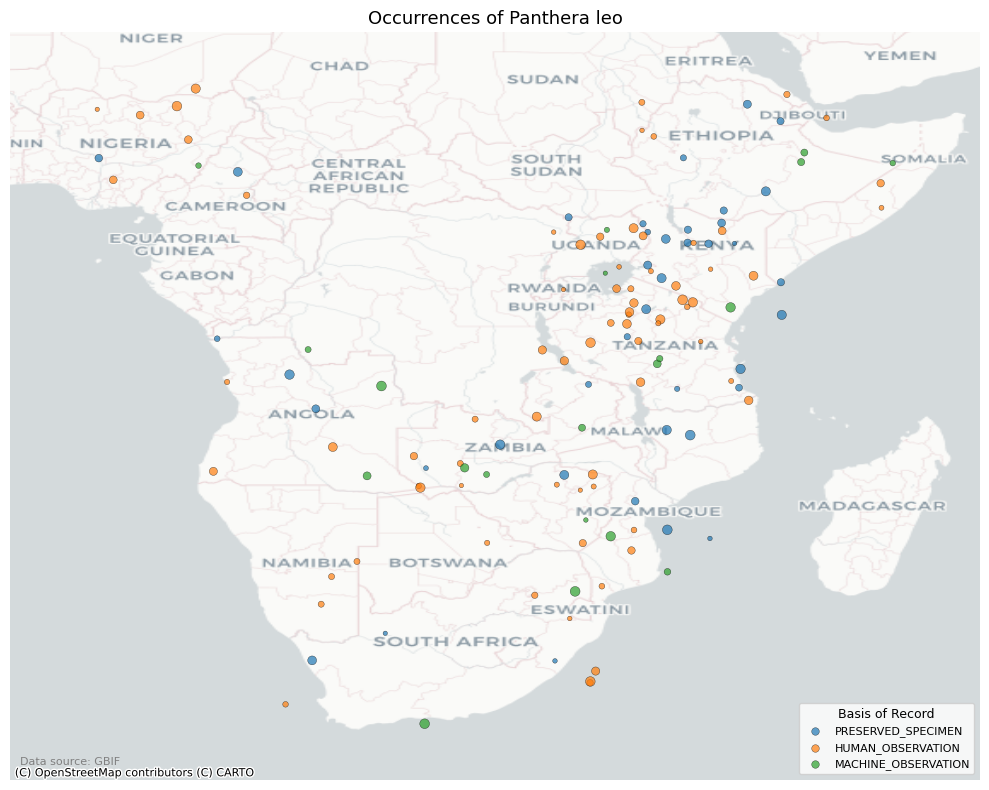

In [14]:
def drawSpeciesOccurrences(ax, occurrences, species_name):
    """
    Draws a point map of all occurrence records for the given species.
    Point colour encodes basisOfRecord; point size encodes recency.
    """
    # Filter for the species
    occur_filt = occurrences[occurrences['species'] == species_name].copy()

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        occur_filt,
        geometry=gpd.points_from_xy(occur_filt['decimalLongitude'], occur_filt['decimalLatitude']),
        crs='EPSG:4326'
    ).to_crs(epsg=3857)

    # Normalize year so more recent translates to a larger point (point size encodes recency)
    year_min, year_max = occur_filt['year'].min(), occur_filt['year'].max()
    if year_max > year_min:
        gdf['size'] = 10 + 40 * (occur_filt['year'] - year_min) / (year_max - year_min)
    else:
        gdf['size'] = 20

    # Color by basisOfRecord
    basis_types = gdf['basisOfRecord'].unique()
    palette = plt.cm.tab10.colors
    colour_map = {b: palette[i % len(palette)] for i, b in enumerate(basis_types)}
    gdf['colour'] = gdf['basisOfRecord'].map(colour_map)

    # Set map extent to bounding box of occurrences + margin
    margin = 500000
    minx, miny, maxx, maxy = gdf.total_bounds
    ax.set_xlim(minx - margin, maxx + margin)
    ax.set_ylim(miny - margin, maxy + margin)

    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Plot points per basisOfRecord category to get a legend
    for basis, colour in colour_map.items():
        subset = gdf[gdf['basisOfRecord'] == basis]
        ax.scatter(
            subset.geometry.x, subset.geometry.y,
            c=[colour], s=subset['size'],
            alpha=0.7, linewidths=0.3, edgecolors='k',
            label=basis
        )

    ax.set_title(f'Occurrences of {species_name}', fontsize=13)
    ax.set_axis_off()
    ax.legend(title='Basis of Record', loc='lower right', fontsize=8, title_fontsize=9)
    ax.annotate('Data source: GBIF', xy=(0.01, 0.02), xycoords='axes fraction',
                fontsize=8, color='grey')
    
#Test
fig, ax = plt.subplots(figsize=(10, 8))
drawSpeciesOccurrences(ax, occurrences, 'Panthera leo')
plt.tight_layout()
plt.savefig('species_occurrences_map.png', dpi=150)
plt.show()

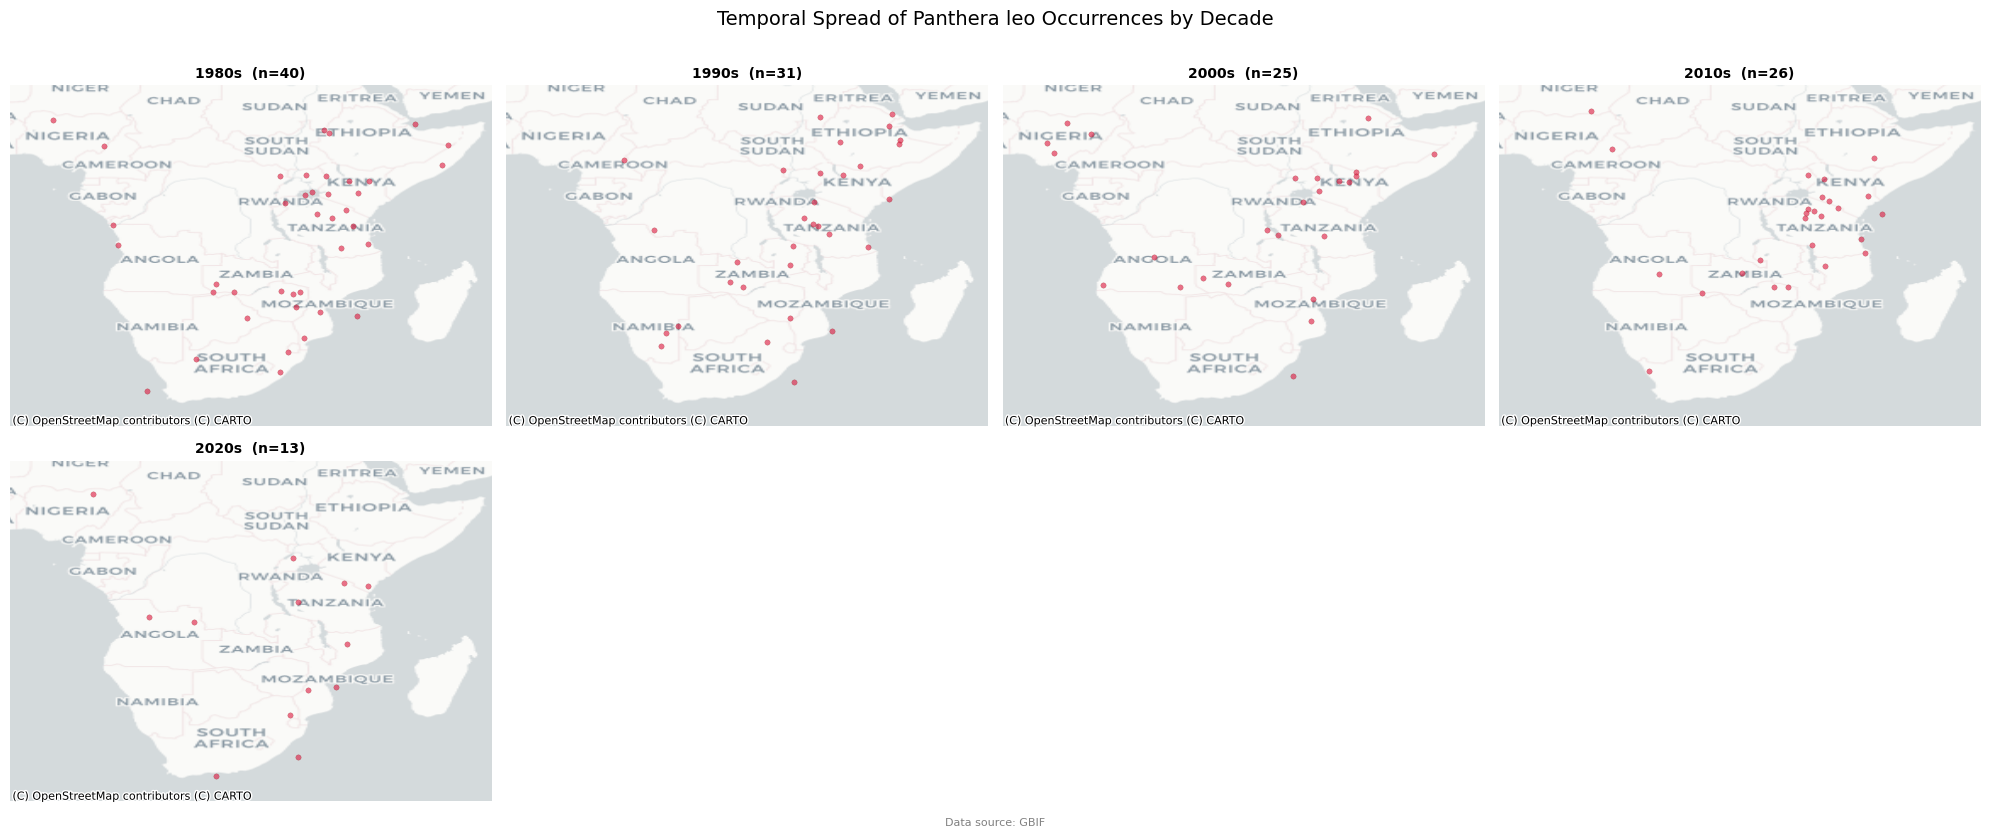

In [15]:
def drawTemporalSpread(occurrences, species_name):
    """
    Draws a multi-panel map showing occurrence records per decade.
    Saves to 'temporal_spread.png'.
    """
    # Filter species and drop missing years/coords
    df = occurrences[occurrences['species'] == species_name].copy()
    df = df.dropna(subset=['year', 'decimalLatitude', 'decimalLongitude'])
    df['decade'] = (df['year'] // 10 * 10).astype(int)

    decades = sorted(df['decade'].unique())
    n = len(decades)
    ncols = 4
    nrows = (n + ncols - 1) // ncols 

    # Convert full species set to GeoDataFrame for bounds
    gdf_all = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['decimalLongitude'], df['decimalLatitude']),
        crs='EPSG:4326'
    ).to_crs(epsg=3857)

    # Global bounding box to ensure consistent extent across panels
    margin = 500000 
    minx, miny, maxx, maxy = gdf_all.total_bounds

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, decade in enumerate(decades):
        ax = axes[i]
        subset = gdf_all[gdf_all['decade'] == decade]

        # Set consistent extent
        ax.set_xlim(minx - margin, maxx + margin)
        ax.set_ylim(miny - margin, maxy + margin)

        # Basemap
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=3)

        # Plot points
        ax.scatter(
            subset.geometry.x, subset.geometry.y,
            s=15, color='crimson', alpha=0.6,
            linewidths=0.2, edgecolors='darkred'
        )

        ax.set_title(f'{decade}s  (n={len(subset)})', fontsize=10, fontweight='bold')
        ax.set_axis_off()

    # Hide any unused panels
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Temporal Spread of {species_name} Occurrences by Decade',
                 fontsize=14, y=1.01)
    fig.text(0.5, -0.01, 'Data source: GBIF', ha='center', fontsize=8, color='grey')

    plt.tight_layout()
    plt.savefig('temporal_spread.png', dpi=150, bbox_inches='tight')
    plt.show()

# Test
drawTemporalSpread(occurrences, 'Panthera leo')